# Persona as a Vector: lộ trình học tiếng Anh theo quỹ đạo persona

Notebook này mở rộng demo cá nhân hóa cho người học tiếng Anh bằng **quỹ đạo persona theo tuần** và **biểu đồ radar (polar)**:

1. Xây thư viện persona (lọc Kalman, khoảng cách, phân đoạn, NBTA, cổng kiểm soát).
2. Sinh dữ liệu mẫu và mô phỏng vòng kín 8 tuần cho 3 chính sách.
3. **Tạo lộ trình tuần-theo-tuần cho từng người học** từ vector hiện tại tới persona mong muốn.
4. Vẽ quỹ đạo bằng radar, so sánh kế hoạch với thực tế, và phát hiện người cần lập lại kế hoạch.

> Toàn bộ dữ liệu là **tổng hợp**. Hiệu quả của từng hành động là giả định trong mô phỏng, nên kết quả chỉ minh họa cơ chế, không phải bằng chứng thực nghiệm.

**Cài đặt:** `pip install numpy pandas matplotlib scikit-learn`

Quy ước bảy chiều (càng cao càng gần trạng thái mong muốn): `V` động lực, `B` thói quen, `N` kỹ năng, `I` ý định, `E` tự tin, `A` mục tiêu rõ, `R` hỗ trợ xã hội. Dấu `*` là chiều được bảo vệ, không bị can thiệp trực tiếp.

In [ ]:
from __future__ import annotations
import csv, os
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10, "font.size": 9})
pd.set_option("display.width", 140, "display.max_colwidth", 60)

## Phần A. Thư viện persona

Các ô A0-A6 giống script `persona_vector_english_learner_demo.py`; chạy lần lượt từ trên xuống.

### A0. Cấu hình: chiều persona, mục tiêu, kiểu người học, danh mục hành động

In [ ]:
DIMS = ["V", "B", "N", "I", "E", "A", "R"]
V, B, N, I, E, A, R = range(7)
DIM_VI = {
    "V": "Động lực", "B": "Thói quen", "N": "Kỹ năng", "I": "Ý định",
    "E": "Tự tin", "A": "Mục tiêu rõ", "R": "Hỗ trợ XH",
}

# Chiều KHÔNG được tác động trực tiếp (paper, Mục 5, 13, 17): giá trị cốt lõi và cảm xúc.
PROTECTED = {"V", "E"}
CTRL = np.array([0.0 if d in PROTECTED else 1.0 for d in DIMS])   # mặt nạ M
D_MAX = np.sqrt(CTRL.sum())                                        # cho PAS

# Persona mong muốn theo mục tiêu mà người học TỰ CHỌN và xác nhận (Mục 4.1).
GOALS = {
    "IELTS 7.0":        np.array([0.80, 0.85, 0.80, 0.90, 0.75, 0.90, 0.50]),
    "Business English": np.array([0.75, 0.80, 0.75, 0.80, 0.85, 0.85, 0.60]),
    "Travel & Chat":    np.array([0.70, 0.70, 0.65, 0.75, 0.80, 0.80, 0.60]),
}

# Ba kiểu người học ẩn (chỉ dùng để sinh dữ liệu; hệ thống KHÔNG biết nhãn này).
ARCHETYPES = {
    #                     V     B     N     I     E     A     R
    "anxious_beginner":  [0.55, 0.25, 0.30, 0.45, 0.25, 0.75, 0.35],
    "busy_inconsistent": [0.70, 0.20, 0.45, 0.50, 0.50, 0.60, 0.30],
    "steady_climber":    [0.65, 0.60, 0.55, 0.65, 0.55, 0.65, 0.50],
}
ARCH_NAMES = list(ARCHETYPES)
ARCH_MEAN = np.array([ARCHETYPES[k] for k in ARCH_NAMES])
ARCH_PROB = [0.40, 0.35, 0.25]


@dataclass(frozen=True)
class Action:
    name: str
    label: str
    effect: tuple              # tỷ lệ khoảng cách được thu hẹp mỗi tuần, theo (V,B,N,I,E,A,R)
    risk: float                # rủi ro ước lượng 0-1
    cost: float = 0.0          # chi phí vận hành tương đối 0-1 (gia sư 1-1 đắt nhất)
    protected_targets: tuple = ()   # chiều bị cấm mà hành động nhắm vào


ACTIONS = [
    Action("micro_lessons", "Bài học 5 phút mỗi ngày",       (0, .30, .10, .05, 0, 0, 0), 0.10, 0.02),
    Action("ai_speaking",   "Bạn luyện nói với AI (không chấm điểm)", (0, .10, .20, 0, 0, 0, 0), 0.10, 0.05),
    Action("spaced_vocab",  "Ôn từ vựng cách quãng",         (0, .10, .28, 0, 0, 0, 0), 0.05, 0.02),
    Action("mock_test",     "Thi thử có phản hồi chi tiết",  (0, 0, .05, .28, 0, .15, 0), 0.40, 0.05),
    Action("goal_planner",  "Lập kế hoạch mục tiêu cá nhân", (0, .05, 0, .12, 0, .32, 0), 0.05, 0.02),
    Action("study_group",   "Nhóm học cùng trình độ",        (0, .10, 0, 0, 0, 0, .35), 0.15, 0.05),
    Action("tutor_session", "Buổi kèm 1-1 với gia sư",       (0, .10, .30, .05, 0, 0, 0), 0.20, 0.30),
    # Hành động thao túng: nhắm vào cảm xúc (lo âu, xấu hổ) để ép duy trì chuỗi ngày.
    # Hiệu quả ngắn hạn "có vẻ" cao, nhưng cổng kiểm soát phải CHẶN.
    Action("streak_shame",  "Thông báo gây áp lực/xấu hổ khi đứt chuỗi",
           (0, .35, 0, 0, 0, 0, 0), 0.30, 0.0, ("E",)),
]
ACT_NAMES = [a.name for a in ACTIONS]
EFFECT = np.array([a.effect for a in ACTIONS], dtype=float)         # (A, 7)
RISK = np.array([a.risk for a in ACTIONS])
COST = np.array([a.cost for a in ACTIONS])
COST_W = 0.10      # trọng số phạt chi phí khi xếp hạng hành động
BLOCKED = np.array([bool(set(a.protected_targets) & PROTECTED) for a in ACTIONS])
GENERIC_ACTION = ACT_NAMES.index("micro_lessons")                    # "một cỡ cho tất cả"

# Độ phù hợp ẩn của từng kiểu người học với từng hành động (ma trận mô phỏng).
#                    micro  ai   vocab mock  plan  group tutor shame
ARCH_AFFINITY = np.array([
    [1.2, 1.5, 1.0, 0.5, 0.9, 0.8, 1.3, 1.0],   # anxious_beginner
    [1.6, 1.0, 1.3, 0.8, 1.2, 0.5, 0.7, 1.0],   # busy_inconsistent
    [0.8, 1.0, 1.0, 1.5, 0.8, 1.3, 1.0, 1.0],   # steady_climber
])

# Tham số lọc Kalman và động lực
Q_DAILY = 0.0015                                              # nhiễu quá trình (persona tự trôi)
R_DIAG = np.array([0.05, 0.05, 0.08, 0.05, 0.06, 0.08, 0.12])  # nhiễu quan sát theo chiều
LAM = 0.35          # tốc độ hội tụ về điểm đặt khi can thiệp hiệu quả
SPILLOVER = 0.5     # năng lực (B, N) tăng thì tự tin (E) tăng theo; KHÔNG nhắm trực tiếp vào E
FATIGUE = 0.85      # lặp lại cùng hành động làm giảm hiệu quả
R_MAX, TAU = 0.50, 0.65   # ngưỡng rủi ro tối đa / độ tin cậy tối thiểu để tự động duyệt

### A1. Lọc Kalman cho persona (Mục 7.1)

In [ ]:
class PersonaFilter:
    """Lọc Kalman đường chéo: F = I, H = I, có quan sát thiếu theo từng chiều."""

    def __init__(self, n, p0=0.5, s0=0.25):
        self.P = np.full((n, 7), p0)     # ước lượng P̂
        self.S = np.full((n, 7), s0)     # phương sai ước lượng (U = sqrt(S))

    def predict(self, days=1):
        self.S = self.S + Q_DAILY * days             # bất định tăng theo thời gian

    def update(self, z, mask, r_scale=1.0):
        K = self.S / (self.S + R_DIAG * r_scale) * mask   # chiều không quan sát: K = 0
        self.P = np.clip(self.P + K * (np.nan_to_num(z) - self.P), 0, 1)
        self.S = (1 - K) * self.S

    def confidence(self):
        """Độ tin cậy 0-1 trên các chiều kiểm soát được."""
        u = np.sqrt(self.S)[:, CTRL.astype(bool)].mean(axis=1)
        return np.clip(1 - u / 0.5, 0, 1)

    def copy(self):
        f = PersonaFilter(len(self.P))
        f.P, f.S = self.P.copy(), self.S.copy()
        return f

### A2. Sinh dữ liệu mẫu: người học và nhật ký phiên học

In [ ]:
@dataclass
class Cohort:
    arch: np.ndarray        # (n,) chỉ số kiểu ẩn
    goal: list              # tên mục tiêu của từng người
    Pd: np.ndarray          # (n,7) persona mong muốn (đã xác nhận)
    P_true: np.ndarray      # (n,7) persona thật (ẩn, chỉ có trong mô phỏng)
    aff: np.ndarray         # (n, A) độ phù hợp ẩn với từng hành động


def make_cohort(n, rng):
    arch = rng.choice(len(ARCH_NAMES), n, p=ARCH_PROB)
    P_true = np.clip(ARCH_MEAN[arch] + rng.normal(0, 0.07, (n, 7)), 0.02, 0.98)
    goal = list(rng.choice(list(GOALS), n))
    Pd = np.array([GOALS[g] for g in goal])
    aff = ARCH_AFFINITY[arch] * rng.lognormal(0, 0.15, (n, len(ACTIONS)))
    return Cohort(arch, goal, Pd, P_true, aff)


def simulate_baseline(cohort, rng, days=28):
    """28 ngày học với nội dung chung (chưa cá nhân hóa). Trả về nhật ký sự kiện,
    bộ lọc đã cập nhật và persona thật cuối kỳ."""
    n = len(cohort.P_true)
    P = cohort.P_true.copy()
    filt = PersonaFilter(n)
    active = np.zeros((n, days), dtype=bool)
    events = []

    for day in range(days):
        filt.predict()
        sess = rng.random(n) < 0.08 + 0.82 * P[:, B]        # khả năng học hôm nay ~ thói quen
        active[:, day] = sess
        idx = np.flatnonzero(sess)
        m = len(idx)
        z = np.full((n, 7), np.nan)
        mask = np.zeros((n, 7))

        if m:
            p = P[idx]
            minutes = np.round(10 + 30 * rng.random(m) * (0.4 + p[:, I])).astype(int)
            quiz_total = rng.integers(3, 9, m)
            quiz_correct = rng.binomial(quiz_total, 0.3 + 0.6 * p[:, N])
            speak_done = rng.binomial(4, p[:, E])      # 4 bài nói được đề xuất mỗi phiên
            exam_done = rng.binomial(5, p[:, I])       # 5 bài bám mục tiêu thi/công việc
            aligned = rng.binomial(5, p[:, V])         # 5 lần chọn nội dung, bao nhiêu lần đúng mục tiêu
            plan_acc = rng.binomial(3, p[:, A])        # 3 gợi ý lập kế hoạch, chấp nhận bao nhiêu
            comm = rng.binomial(2, p[:, R])            # 2 gợi ý cộng đồng, tương tác bao nhiêu

            # Đặc trưng hành vi -> quan sát z (chuẩn hóa về [0,1], gần không chệch)
            z[idx, V] = aligned / 5
            z[idx, N] = np.clip((quiz_correct / quiz_total - 0.3) / 0.6, 0, 1)
            z[idx, I] = exam_done / 5
            z[idx, E] = speak_done / 4
            z[idx, A] = plan_acc / 3
            z[idx, R] = comm / 2
            mask[idx[:, None], [V, N, I, E, A, R]] = 1.0

            for k, i in enumerate(idx):
                events.append((int(i), day, int(minutes[k]), int(quiz_total[k]),
                               int(quiz_correct[k]), int(speak_done[k]),
                               int(exam_done[k]), int(aligned[k]),
                               int(plan_acc[k]), int(comm[k])))
            # học thật thì kỹ năng và sự tự tin tăng nhẹ
            P[idx, N] += 0.004 * minutes / 30 * (1 - P[idx, N])
            P[idx, E] += 0.004 * speak_done * (1 - P[idx, E])

        if day >= 6:                                    # chuyên cần: tỷ lệ ngày học trong 7 ngày
            frac = active[:, day - 6:day + 1].mean(axis=1)
            z[:, B] = np.clip((frac - 0.08) / 0.82, 0, 1)
            mask[:, B] = 1.0

        filt.update(z, mask)
        P = np.clip(P + rng.normal(0, 0.003, P.shape), 0, 1)

    return events, filt, P

### A3. Khoảng cách, PAS (Mục 4)

In [ ]:
def tg(P, Pd):
    """Transformation Gap trên các chiều kiểm soát được."""
    return np.sqrt((((Pd - P) * CTRL) ** 2).sum(axis=-1))


def pas(P, Pd):
    return 1 - tg(P, Pd) / D_MAX


def dist_u(P, Pd, S):
    """Khoảng cách có trọng số theo bất định (Mục 4.3), chiều kém tin cậy đóng góp ít hơn."""
    w = 1 / (1 + np.sqrt(S))
    w = w / w.mean(axis=-1, keepdims=True)
    return np.sqrt((w * ((Pd - P) * CTRL) ** 2).sum(axis=-1))

### A4. Phân đoạn theo vector persona (Mục 11)

In [ ]:
GAP_LABEL = {"V": "Ít động lực", "B": "Học thất thường", "N": "Hổng kỹ năng",
             "I": "Ý định yếu", "E": "Thiếu tự tin", "A": "Chưa rõ mục tiêu",
             "R": "Học một mình"}


def fit_segments(P_hat, k=3, seed=0):
    km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(P_hat)
    names = []
    for c in km.cluster_centers_:
        low = np.argsort(c)[:2]                                    # hai chiều thấp nhất
        names.append(" + ".join(GAP_LABEL[DIMS[j]] for j in low))
    return km, names


def segment_stability(P_hat, km, rng, runs=15):
    aris = []
    for s in range(runs):
        idx = rng.choice(len(P_hat), len(P_hat), replace=True)
        kb = KMeans(n_clusters=km.n_clusters, n_init=10, random_state=s).fit(P_hat[idx])
        aris.append(adjusted_rand_score(km.labels_, kb.predict(P_hat)))
    return float(np.mean(aris)), float(np.min(aris))

### A5. Next Best Transformation Action và cổng kiểm soát (Mục 12, 13)

In [ ]:
def guardrail(action: Action, conf: float, r_max=R_MAX, tau=TAU) -> str:
    if set(action.protected_targets) & PROTECTED:
        return "block"                       # nhắm vào chiều bất khả xâm phạm
    if action.risk > r_max or conf < tau:
        return "human_review"                # rủi ro cao hoặc ước lượng chưa đủ tin cậy
    return "auto_approve"


def expected_reduction(P_hat, Pd):
    """Mức giảm TG kỳ vọng của từng hành động (xấp xỉ gradient): Σ eff_d · gap_d² / ||gap||."""
    gap = np.maximum(Pd - P_hat, 0) * CTRL
    norm = np.sqrt((gap ** 2).sum(axis=1)) + 1e-9
    return LAM * (gap ** 2 @ EFFECT.T) / norm[:, None]               # (n, A)


def net_score(P_hat, Pd):
    """Mức giảm TG kỳ vọng trừ phạt chi phí vận hành."""
    return expected_reduction(P_hat, Pd) - COST_W * COST[None, :]


def nbta_choose(P_hat, Pd, conf, seg, alpha, beta, rng, top_k=3):
    """Lọc top-k hành động theo mức thu hẹp khoảng cách, rồi dùng Thompson Sampling
    theo segment để chọn trong top-k (học độ phù hợp thật từ phản hồi)."""
    n = len(P_hat)
    score = net_score(P_hat, Pd)
    blocked_top = int(BLOCKED[np.argmax(score, axis=1)].sum())       # tối ưu "thuần" sẽ chọn hành động bị cấm
    score[:, BLOCKED] = -np.inf                                      # hành động bị cấm không bao giờ vào
    top = np.argsort(-score, axis=1)[:, :top_k]
    chosen = np.full(n, -1)
    verdict = np.empty(n, dtype=object)
    for i in range(n):
        theta = rng.beta(alpha[seg[i], top[i]], beta[seg[i], top[i]])
        a = int(top[i][int(np.argmax(theta))])
        v = guardrail(ACTIONS[a], conf[i])
        verdict[i] = v
        if v == "auto_approve":
            chosen[i] = a                                            # human_review: không tự thực thi
    return chosen, verdict, blocked_top

### A6. Mô phỏng vòng kín nhiều tuần, có ghi lại quỹ đạo (Mục 10)

In [ ]:
def run_arm(policy, cohort, filt0, P_true0, km, weeks, seed):
    """Chạy một chính sách từ CÙNG trạng thái ban đầu và CÙNG nhiễu ngẫu nhiên
    (common random numbers), nên khác biệt giữa các nhánh chỉ đến từ hành động."""
    n = len(P_true0)
    P = P_true0.copy()
    filt = filt0.copy()
    Pd = cohort.Pd
    n_seg = km.n_clusters
    alpha = np.ones((n_seg, len(ACTIONS)))
    beta = np.ones((n_seg, len(ACTIONS)))
    policy_rng = np.random.default_rng(seed + 999)
    last_a = np.full(n, -1)
    rep = np.zeros(n)
    log = {"tv": [], "review": 0, "auto": 0, "blocked": 0, "cost": 0.0, "picks": np.zeros((n_seg, len(ACTIONS)))}
    tg_start = tg(P, Pd).mean()
    traj, hat_traj, acts = [P.copy()], [filt.P.copy()], []   # quỹ đạo thật, quỹ đạo ước lượng, hành động

    for w in range(weeks):
        rng_w = np.random.default_rng(seed * 1000 + w)               # nhiễu chung giữa các nhánh
        noise_true = rng_w.normal(0, 0.01, (n, 7))
        noise_obs = rng_w.normal(0, 1, (n, 7))

        P_hat_before = filt.P.copy()
        tg_hat_before = tg(P_hat_before, Pd)
        seg = km.predict(P_hat_before)

        if policy == "control":
            a = np.full(n, -1)
        elif policy == "generic":
            a = np.full(n, GENERIC_ACTION)
        else:
            a, verdict, blocked_top = nbta_choose(P_hat_before, Pd, filt.confidence(), seg,
                                                  alpha, beta, policy_rng)
            log["review"] += int((verdict == "human_review").sum())
            log["auto"] += int((verdict == "auto_approve").sum())
            log["blocked"] += blocked_top

        # --- cập nhật persona THẬT dưới tác động của hành động ---
        has = a >= 0
        log["cost"] += float(COST[a[has]].sum()) if has.any() else 0.0
        rep = np.where(has & (a == last_a), rep + 1, 0)
        last_a = np.where(has, a, last_a)
        gap_true = np.maximum(Pd - P, 0)
        g = np.zeros((n, 7))
        if has.any():
            resp = cohort.aff[has, a[has]] * FATIGUE ** rep[has]
            g[has] = LAM * EFFECT[a[has]] * gap_true[has] * resp[:, None]
        g[:, E] += SPILLOVER * (g[:, B] + g[:, N]) / 2               # tự tin tăng như hệ quả của năng lực
        natural = 0.01 * gap_true                                    # tiến bộ tự nhiên nhỏ
        tg_true_before = tg(P, Pd)
        P = np.clip(P + g + natural + noise_true, 0, 1)
        log["tv"].append(float((tg_true_before - tg(P, Pd)).mean()))

        traj.append(P.copy())
        acts.append(a.copy())
        # --- quan sát cuối tuần, cập nhật bộ lọc ---
        z = np.clip(P + noise_obs * np.sqrt(R_DIAG / 2), 0, 1)
        filt.predict(7)
        filt.update(z, np.ones((n, 7)), r_scale=0.5)
        hat_traj.append(filt.P.copy())

        # --- phản hồi cho bandit: người học có tiến triển (theo ước lượng) không? ---
        if policy == "nbta":
            progress = ((tg_hat_before - tg(filt.P, Pd)) > 0.03).astype(float)
            for i in np.flatnonzero(has):
                alpha[seg[i], a[i]] += progress[i]
                beta[seg[i], a[i]] += 1 - progress[i]
                log["picks"][seg[i], a[i]] += 1

    log.update(tg_start=float(tg_start), tg_end=float(tg(P, Pd).mean()),
               pas_end=float(pas(P, Pd).mean()),
               reached=float((pas(P, Pd) >= 0.85).mean()),
               tv_mean=float(np.mean(log["tv"])), P_end=P,
               cost_per_week=log["cost"] / (n * weeks),
               traj=np.array(traj), hat_traj=np.array(hat_traj), acts=np.array(acts),
               alpha=alpha, beta=beta)
    return log

## Phần B. Chạy mô phỏng

Sinh người học, mô phỏng 28 ngày nền, ước lượng persona, phân đoạn, rồi chạy 3 chính sách (đối chứng, chung, NBTA) trong 8 tuần từ cùng trạng thái đầu và cùng nhiễu.

In [ ]:
SEED, N_LEARNERS, WEEKS = 42, 300, 8
rng = np.random.default_rng(SEED)

cohort = make_cohort(N_LEARNERS, rng)
events, filt, P_true_now = simulate_baseline(cohort, rng)
km, seg_names = fit_segments(filt.P, k=3, seed=SEED)

arms = {p: run_arm(p, cohort, filt, P_true_now, km, WEEKS, SEED) for p in ("control", "generic", "nbta")}
label = {"control": "Đối chứng", "generic": "Chung (bài 5 phút)", "nbta": "NBTA cá nhân hóa"}

summary = pd.DataFrame({
    label[p]: {"TG đầu": r["tg_start"], "TG cuối": r["tg_end"], "TV/tuần": r["tv_mean"],
               "PAS cuối": r["pas_end"], "% đạt PAS≥0.85": 100 * r["reached"], "Chi phí/tuần": r["cost_per_week"]}
    for p, r in arms.items()}).T.round(3)
print(f"{N_LEARNERS} người học, {len(events)} phiên học nền; silhouette={silhouette_score(filt.P, km.labels_):.2f}")
for k in range(3):
    print(f"Segment {k}: {seg_names[k]} (n={(km.labels_ == k).sum()})")
summary

300 người học, 2842 phiên học nền; silhouette=0.23
Segment 0: Thiếu tự tin + Học thất thường (n=118)
Segment 1: Học thất thường + Học một mình (n=113)
Segment 2: Học một mình + Hổng kỹ năng (n=69)


,TG đầu,TG cuối,TV/tuần,PAS cuối,% đạt PAS≥0.85,Chi phí/tuần
Đối chứng,0.727,0.673,0.007,0.699,10.333,0.000
Chung (bài 5 phút),0.727,0.504,0.028,0.774,14.000,0.020
NBTA cá nhân hóa,0.727,0.470,0.032,0.790,17.333,0.025


## Phần C. Lộ trình học theo quỹ đạo persona

Từ vector ước lượng hiện tại $\hat{\mathbf P}_0$ và persona mong muốn $\mathbf P^*$ (do người học xác nhận), hàm `build_roadmap` **chiếu tới trước từng tuần** bằng mô hình kỳ vọng (không nhiễu):

$$
\mathbf P_{w+1}=\mathbf P_w+\lambda\,\mathbf e_{a}\odot(\mathbf P^*-\mathbf P_w)\cdot r_a\cdot \text{fatigue}+\text{spillover}
$$

Mỗi tuần chọn hành động có điểm ròng cao nhất (giảm khoảng cách kỳ vọng trừ phạt chi phí), **xoay vòng** để tránh mệt mỏi vì lặp lại, bỏ qua hành động bị cổng kiểm soát chặn, và đánh dấu tuần cần người duyệt khi độ tin cậy thấp. Hệ số phù hợp $r_a$ lấy từ phản hồi mà bandit đã học ở segment của người đó.

In [ ]:
ROTATION = 0.60      # hệ số phạt cho mỗi lần hoạt động đã dùng trong 2 tuần gần nhất (khi lập kế hoạch)


def build_roadmap(i, weeks=WEEKS, lo_conf=None):
    """Lộ trình tuần-theo-tuần cho người học i. Trả về (DataFrame, quỹ đạo kế hoạch (weeks+1, 7))."""
    P = filt.P[i].copy()
    Pd = cohort.Pd[i]
    conf = filt.confidence()[i] if lo_conf is None else lo_conf
    seg = int(km.predict(P[None])[0])
    a_, b_ = arms["nbta"]["alpha"][seg], arms["nbta"]["beta"][seg]
    resp = np.clip((a_ / (a_ + b_)) / (a_ / (a_ + b_)).mean(), 0.5, 1.5)   # độ phù hợp học được của segment

    traj, rows, history = [P.copy()], [], []
    last, run = -1, 0
    for w in range(1, weeks + 1):
        net = net_score(P[None], Pd[None])[0] * resp
        for a_used in history[-2:]:                                # xen kẽ: phạt hoạt động đã dùng 2 tuần gần nhất
            if net[a_used] > 0:
                net[a_used] *= ROTATION
        net[BLOCKED] = -np.inf                                     # hành động bị cấm không bao giờ vào kế hoạch
        order = np.argsort(-net)
        verdicts = {a: guardrail(ACTIONS[a], conf) for a in order[:4]}
        a = next((x for x in order if verdicts.get(x) == "auto_approve"), order[0])
        verdict = verdicts.get(a, guardrail(ACTIONS[a], conf))

        gap = np.maximum(Pd - P, 0)
        fatigue = FATIGUE ** (run + 1) if a == last else 1.0
        g = LAM * EFFECT[a] * gap * resp[a] * fatigue
        g[E] += SPILLOVER * (g[B] + g[N]) / 2
        P_new = np.clip(P + g + 0.01 * gap, 0, 1)

        move = (P_new - P) * CTRL                                   # chỉ xét chiều kiểm soát được
        focus = [DIMS[j] for j in np.argsort(-move)[:2] if move[j] > 1e-4]
        run = run + 1 if a == last else 0
        last, P = a, P_new
        history.append(int(a))
        traj.append(P.copy())
        rows.append({
            "Tuần": w,
            "Hoạt động chính": ACTIONS[a].label,
            "Tập trung": " + ".join(DIM_VI[d] for d in focus),
            "Cột mốc cuối tuần": "; ".join(f"{DIM_VI[d]} ≈ {P[DIMS.index(d)]:.2f}" for d in focus),
            "TG kế hoạch": round(float(tg(P, Pd)), 3),
            "PAS kế hoạch": round(float(pas(P, Pd)), 3),
            "Duyệt": {"auto_approve": "tự động", "human_review": "cần người duyệt"}.get(verdict, verdict),
        })
    return pd.DataFrame(rows), np.array(traj)


# Chọn 3 người học tiêu biểu: mỗi kiểu ẩn một người
sample = {ARCH_NAMES[k]: int(np.flatnonzero(cohort.arch == k)[0]) for k in range(3)}
print("Người học mẫu:", sample)
i0 = sample["anxious_beginner"]
plan0, plan_traj0 = build_roadmap(i0)
print(f"Người học #{i0} | mục tiêu: {cohort.goal[i0]} | segment: {seg_names[int(km.predict(filt.P[i0][None])[0])]} "
      f"| TG hiện tại {tg(filt.P[i0], cohort.Pd[i0]):.2f} | độ tin cậy {filt.confidence()[i0]:.2f}")
plan0

Người học mẫu: {'anxious_beginner': 4, 'busy_inconsistent': 1, 'steady_climber': 0}
Người học #4 | mục tiêu: Business English | segment: Học thất thường + Học một mình | TG hiện tại 0.76 | độ tin cậy 0.75


,Tuần,Hoạt động chính,Tập trung,Cột mốc cuối tuần,TG kế hoạch,PAS kế hoạch,Duyệt
0,1,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.29; Kỹ năng ≈ 0.48,0.692,0.691,tự động
1,2,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.35; Kỹ năng ≈ 0.50,0.641,0.713,tự động
2,3,Ôn từ vựng cách quãng,Kỹ năng + Thói quen,Kỹ năng ≈ 0.52; Thói quen ≈ 0.37,0.616,0.724,tự động
3,4,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.43; Kỹ năng ≈ 0.53,0.568,0.746,tự động
4,5,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.47; Kỹ năng ≈ 0.54,0.532,0.762,tự động
5,6,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.69; Ý định ≈ 0.56,0.510,0.772,tự động
6,7,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.52; Kỹ năng ≈ 0.55,0.475,0.787,tự động
7,8,Bài học 5 phút mỗi ngày,Thói quen + Kỹ năng,Thói quen ≈ 0.55; Kỹ năng ≈ 0.56,0.449,0.799,tự động


## Phần D. Biểu đồ radar (polar)

Mỗi trục là một chiều persona; đa giác càng phình ra càng gần trạng thái mong muốn. Đường nét đứt đen là **persona mong muốn** $\mathbf P^*$.

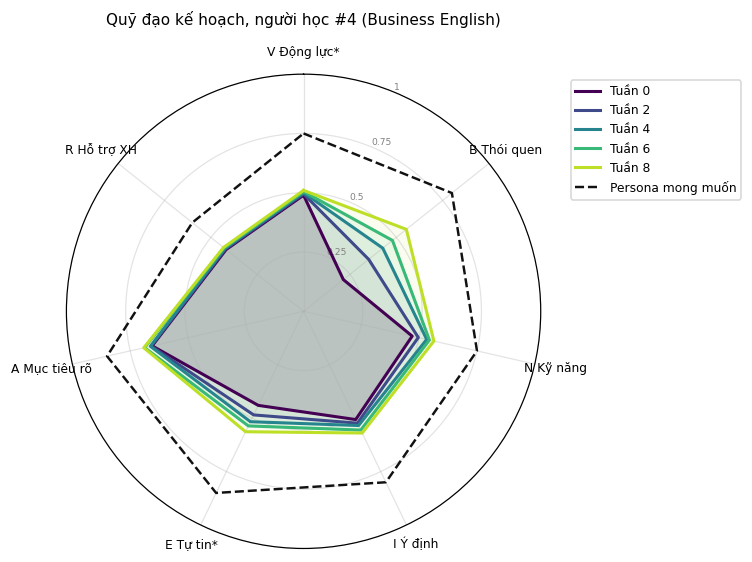

In [ ]:
ANGLES = np.linspace(0, 2 * np.pi, len(DIMS), endpoint=False)
LABELS = [f"{d} {DIM_VI[d]}{'*' if d in PROTECTED else ''}" for d in DIMS]
_close = lambda v: np.r_[np.asarray(v, float), float(np.asarray(v)[0])]
_ang = np.r_[ANGLES, 2 * np.pi]


def new_radar(ax=None, title=None, size=(5.6, 5.6)):
    if ax is None:
        _, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=size)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(ANGLES)
    ax.set_xticklabels(LABELS, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1"], fontsize=6, color="gray")
    ax.grid(alpha=0.35)
    if title:
        ax.set_title(title, pad=14)
    return ax


def draw(ax, v, color, label=None, fill=True, ls="-", lw=2.0, alpha=0.15):
    ax.plot(_ang, _close(v), color=color, lw=lw, ls=ls, label=label)
    if fill:
        ax.fill(_ang, _close(v), color=color, alpha=alpha)


TARGET_STYLE = dict(color="#111", ls="--", lw=1.6, fill=False)
wk_color = lambda w, W: plt.cm.viridis(0.9 * w / max(W, 1))

# D1. Quỹ đạo kế hoạch của một người học: các tuần 0, 2, 4, 6, 8 chồng lên nhau
ax = new_radar(title=f"Quỹ đạo kế hoạch, người học #{i0} ({cohort.goal[i0]})")
for w in (0, 2, 4, 6, WEEKS):
    draw(ax, plan_traj0[w], wk_color(w, WEEKS), label=f"Tuần {w}", alpha=0.07 if w else 0.18)
draw(ax, cohort.Pd[i0], label="Persona mong muốn", **TARGET_STYLE)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), fontsize=8)
plt.show()

### D2. Lộ trình từng tuần (lưới radar)

Mỗi ô là trạng thái dự kiến cuối tuần; tiêu đề ghi hoạt động chính, TG và PAS.

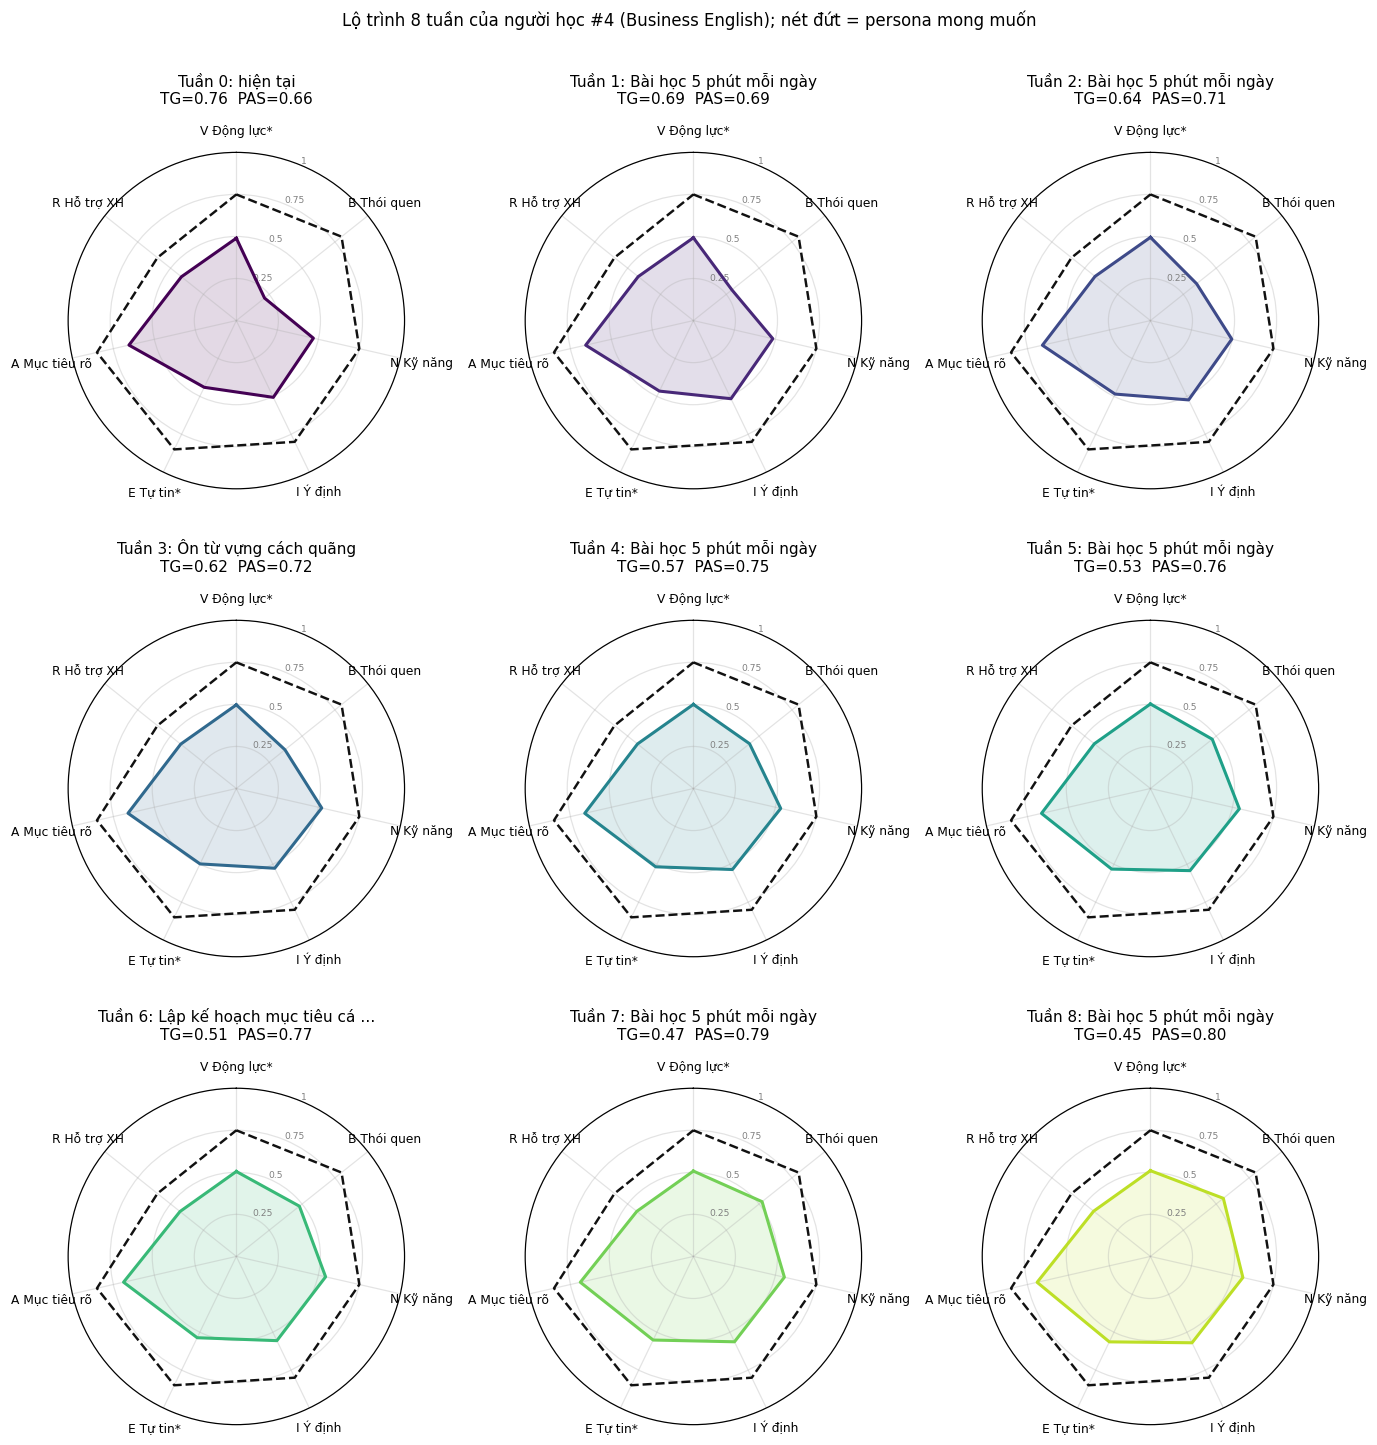

In [ ]:
def short(txt, n=26):
    return txt if len(txt) <= n else txt[: n - 1] + "…"

def roadmap_grid(i, plan_df, plan_traj, ncols=3):
    W = len(plan_traj) - 1
    n_panels = W + 1
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, subplot_kw=dict(polar=True), figsize=(4.2 * ncols, 4.4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for w in range(n_panels):
        ttl = (f"Tuần 0: hiện tại\nTG={tg(plan_traj[0], cohort.Pd[i]):.2f}  PAS={pas(plan_traj[0], cohort.Pd[i]):.2f}" if w == 0 else
               f"Tuần {w}: {short(plan_df.loc[w - 1, 'Hoạt động chính'])}\n"
               f"TG={plan_df.loc[w - 1, 'TG kế hoạch']:.2f}  PAS={plan_df.loc[w - 1, 'PAS kế hoạch']:.2f}")
        new_radar(axes[w], ttl)
        draw(axes[w], plan_traj[w], wk_color(w, W))
        draw(axes[w], cohort.Pd[i], **TARGET_STYLE)
    for ax in axes[n_panels:]:
        ax.axis("off")
    fig.suptitle(f"Lộ trình {W} tuần của người học #{i} ({cohort.goal[i]}); nét đứt = persona mong muốn", y=1.0)
    fig.tight_layout()
    plt.show()

roadmap_grid(i0, plan0, plan_traj0)

### D3. Ba kiểu người học, cùng một mục tiêu nhưng lộ trình khác nhau

So sánh tuần 0 và tuần 8 theo kế hoạch cho ba người học mẫu.

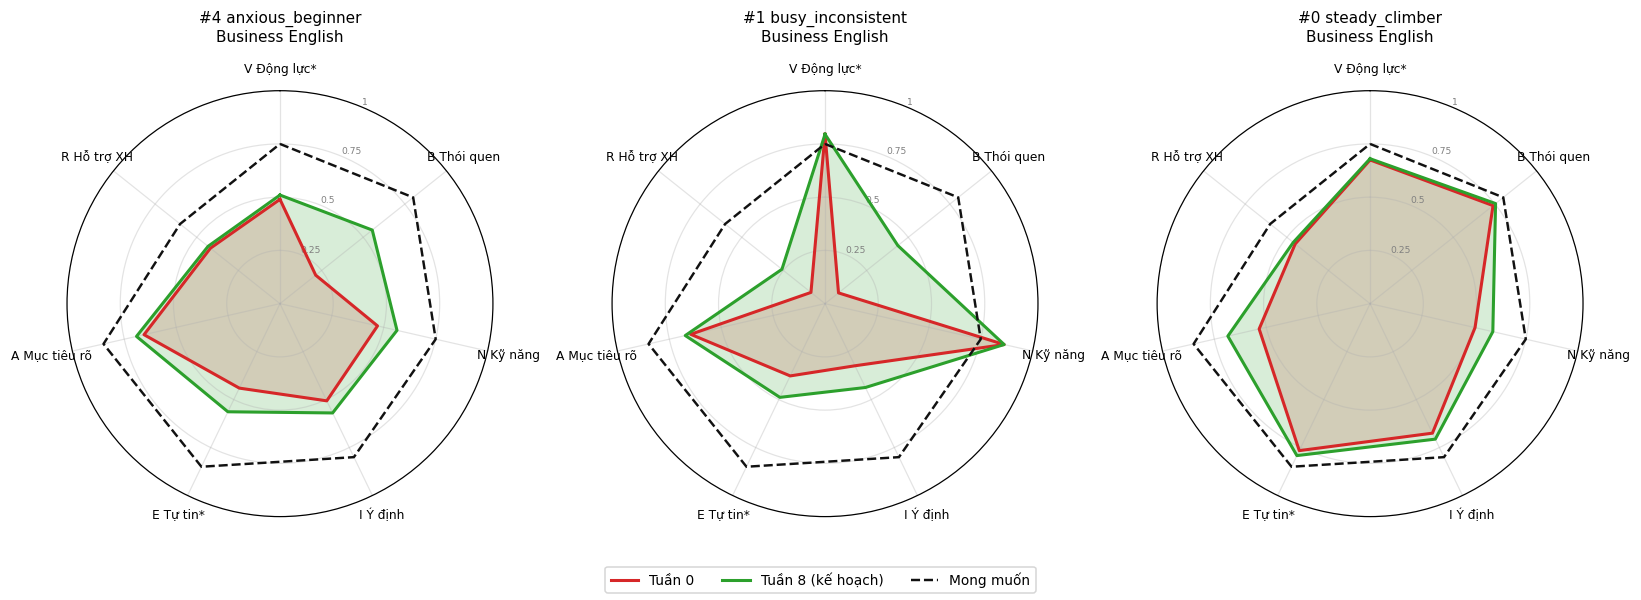

#4 anxious_beginner   hoạt động tuần 1-4: Bài học 5 phút mỗi ng… > Bài học 5 phút mỗi ng… > Ôn từ vựng cách quãng > Bài học 5 phút mỗi ng…
#1 busy_inconsistent  hoạt động tuần 1-4: Bài học 5 phút mỗi ng… > Nhóm học cùng trình độ > Bài học 5 phút mỗi ng… > Bài học 5 phút mỗi ng…
#0 steady_climber     hoạt động tuần 1-4: Lập kế hoạch mục tiêu… > Ôn từ vựng cách quãng > Lập kế hoạch mục tiêu… > Lập kế hoạch mục tiêu…


In [ ]:
fig, axes = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(15, 5.4))
plans = {}
for ax, (name, i) in zip(axes, sample.items()):
    df, tj = build_roadmap(i)
    plans[i] = (df, tj)
    new_radar(ax, f"#{i} {name}\n{cohort.goal[i]}")
    draw(ax, tj[0], "#d62728", label="Tuần 0", alpha=0.18)
    draw(ax, tj[-1], "#2ca02c", label=f"Tuần {WEEKS} (kế hoạch)", alpha=0.18)
    draw(ax, cohort.Pd[i], label="Mong muốn", **TARGET_STYLE)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

for name, i in sample.items():
    df = plans[i][0]
    print(f"#{i} {name:<18} hoạt động tuần 1-4:", " > ".join(df['Hoạt động chính'][:4].map(lambda s: short(s, 22))))

### D4. Kế hoạch so với thực tế (vòng kín)

Kế hoạch là dự báo; thực tế còn chịu nhiễu và phản hồi. Biểu đồ trái: khoảng cách TG của một người học theo kế hoạch, theo persona thật (mô phỏng, ẩn) và theo ước lượng của bộ lọc. Biểu đồ phải: TG trung bình toàn nhóm của ba chính sách.

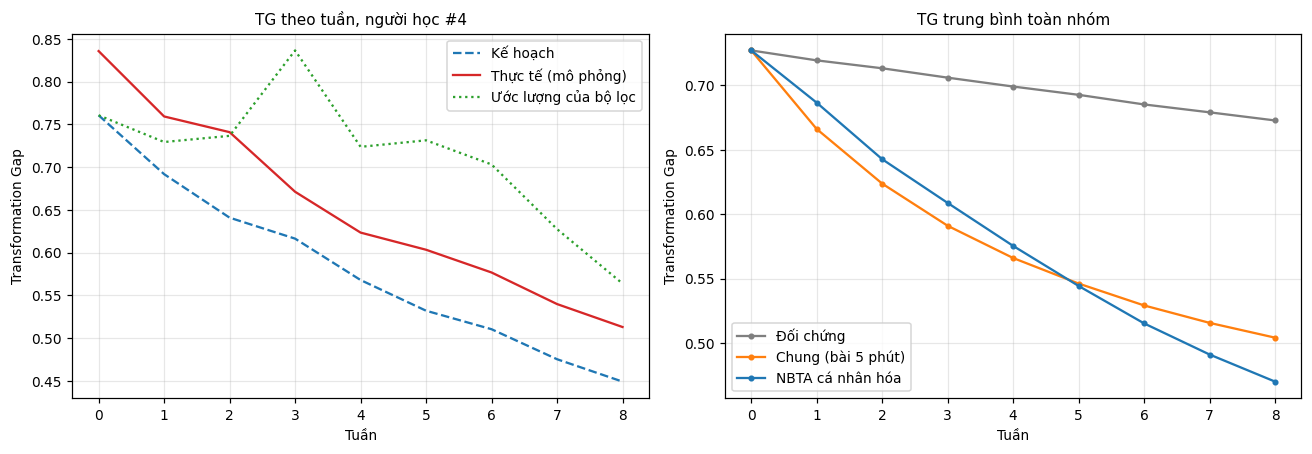

In [ ]:
def tg_series(traj_arr, Pd):           # traj_arr: (weeks+1, n, 7)
    return np.array([tg(traj_arr[w], Pd) for w in range(len(traj_arr))])

nb = arms["nbta"]
tg_true = tg_series(nb["traj"], cohort.Pd)        # (weeks+1, n)
tg_hat = tg_series(nb["hat_traj"], cohort.Pd)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
wk = np.arange(WEEKS + 1)
a1.plot(wk, [tg(p, cohort.Pd[i0]) for p in plan_traj0], "--", color="#1f77b4", label="Kế hoạch")
a1.plot(wk, tg_true[:, i0], "-", color="#d62728", label="Thực tế (mô phỏng)")
a1.plot(wk, tg_hat[:, i0], ":", color="#2ca02c", label="Ước lượng của bộ lọc")
a1.set(title=f"TG theo tuần, người học #{i0}", xlabel="Tuần", ylabel="Transformation Gap")
a1.legend(); a1.grid(alpha=0.3)

for p, c in zip(("control", "generic", "nbta"), ("#7f7f7f", "#ff7f0e", "#1f77b4")):
    a2.plot(wk, tg_series(arms[p]["traj"], cohort.Pd).mean(axis=1), "-o", ms=3, color=c, label=label[p])
a2.set(title="TG trung bình toàn nhóm", xlabel="Tuần", ylabel="Transformation Gap")
a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### D5. Quỹ đạo trung bình theo segment

Gom người học theo segment lúc bắt đầu, vẽ vector trung bình tuần 0 và tuần cuối (nhánh NBTA) so với persona mong muốn trung bình.

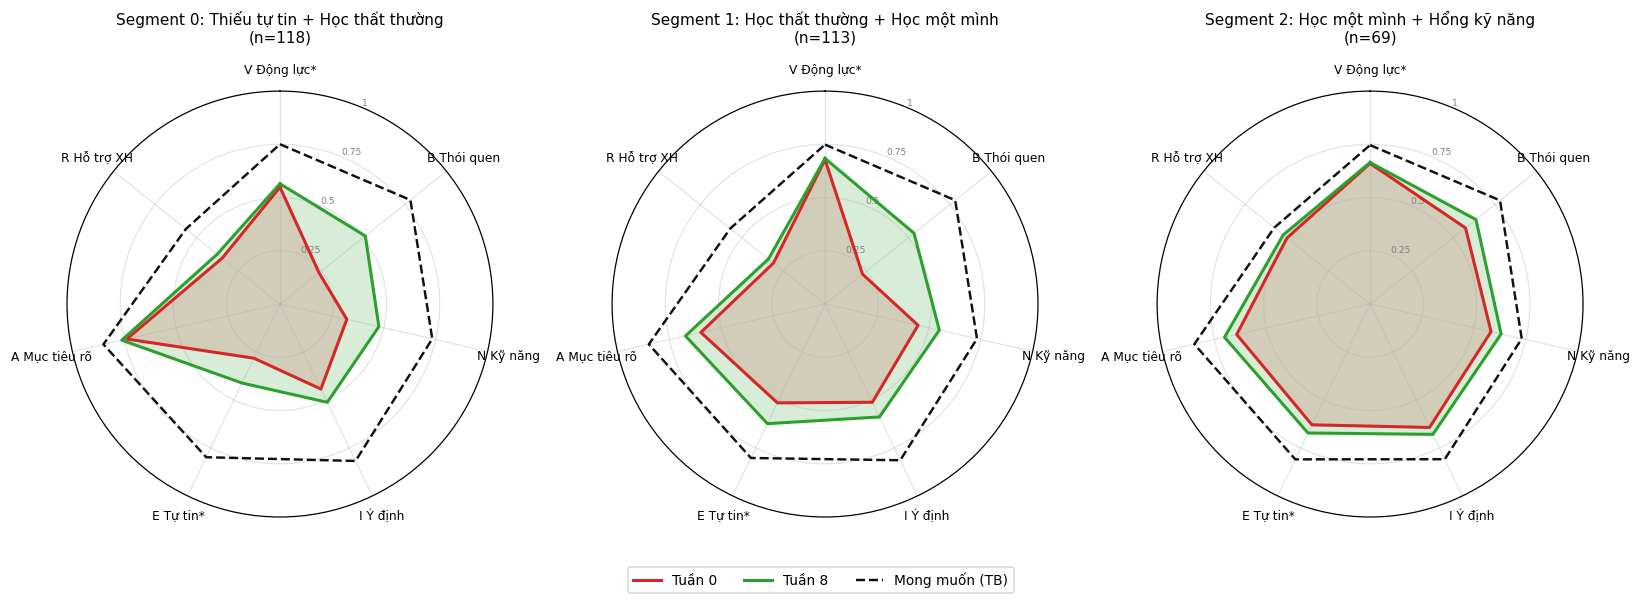

In [ ]:
seg0 = km.predict(nb["hat_traj"][0])
fig, axes = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(15, 5.4))
for k, ax in enumerate(axes):
    m = seg0 == k
    new_radar(ax, f"Segment {k}: {seg_names[k]}\n(n={m.sum()})")
    draw(ax, nb["traj"][0][m].mean(axis=0), "#d62728", label="Tuần 0", alpha=0.18)
    draw(ax, nb["traj"][-1][m].mean(axis=0), "#2ca02c", label=f"Tuần {WEEKS}", alpha=0.18)
    draw(ax, cohort.Pd[m].mean(axis=0), label="Mong muốn (TB)", **TARGET_STYLE)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

## Phần E. Từ quỹ đạo tới lộ trình có thể giao cho người học

1. **Phát hiện cần lập lại kế hoạch:** nếu TG theo ước lượng lớn hơn TG kế hoạch quá ngưỡng trong hai tuần liền, chuyển sang lập lại (đóng vòng điều khiển).
2. **Thông điệp lộ trình:** văn bản thân thiện, nói rõ mục tiêu do người học chọn, có thể đổi bất cứ lúc nào, không dùng áp lực hay xấu hổ.
3. **Xuất CSV** cho toàn bộ người học.

In [ ]:
# E1. Lập lộ trình cho toàn bộ người học và phát hiện người cần lập lại kế hoạch
all_plans = {i: build_roadmap(i) for i in range(N_LEARNERS)}
plan_tg = np.array([[tg(all_plans[i][1][w], cohort.Pd[i]) for i in range(N_LEARNERS)] for w in range(WEEKS + 1)])   # (W+1, n)

CONSEC = 2
# Ngưỡng theo bất định của bộ lọc (phương pháp delta): sd(TG) = sqrt(Σ (gap_d/TG)² · S_d); ngưỡng = 2·sd (tối thiểu 0.05)
gap0 = np.maximum(cohort.Pd - filt.P, 0) * CTRL
sd_tg = np.sqrt(((gap0 / (np.linalg.norm(gap0, axis=1, keepdims=True) + 1e-9)) ** 2 * filt.S).sum(axis=1))
tol = np.maximum(2 * sd_tg, 0.05)                                 # (n,)

over = (tg_hat - plan_tg) > tol[None, :]                          # thực tế (ước lượng) tệ hơn kế hoạch quá ngưỡng
run_len = np.zeros(N_LEARNERS, int); flag = np.zeros(N_LEARNERS, bool)
for w in range(1, WEEKS + 1):
    run_len = np.where(over[w], run_len + 1, 0)
    flag |= run_len >= CONSEC
print(f"Ngưỡng TB = {tol.mean():.3f} (2 lần độ lệch chuẩn của TG theo bộ lọc)")
print(f"Cần lập lại kế hoạch (TG thực tế vượt kế hoạch quá ngưỡng trong {CONSEC} tuần liền): "
      f"{flag.sum()}/{N_LEARNERS} người ({flag.mean():.0%})")
print("Theo kiểu ẩn:", {ARCH_NAMES[k]: f"{flag[cohort.arch == k].mean():.0%}" for k in range(3)})
print(f"TG kế hoạch cuối TB {plan_tg[-1].mean():.3f}  |  TG thực tế cuối TB (nhánh NBTA) {tg_true[-1].mean():.3f}")

Ngưỡng TB = 0.245 (2 lần độ lệch chuẩn của TG theo bộ lọc)
Cần lập lại kế hoạch (TG thực tế vượt kế hoạch quá ngưỡng trong 2 tuần liền): 23/300 người (8%)
Theo kiểu ẩn: {'anxious_beginner': '11%', 'busy_inconsistent': '6%', 'steady_climber': '4%'}
TG kế hoạch cuối TB 0.459  |  TG thực tế cuối TB (nhánh NBTA) 0.470


In [ ]:
# E2. Thông điệp lộ trình cho người học (có thể đưa vào app hoặc email)
def roadmap_message(i, max_weeks=4):
    df, tj = all_plans[i]
    focus_now = [DIM_VI[DIMS[j]] for j in np.argsort(-((cohort.Pd[i] - tj[0]) * CTRL))[:2]]
    lines = [
        f"Lộ trình {WEEKS} tuần cho mục tiêu **{cohort.goal[i]}**",
        f"Hiện tại bạn đang gần mục tiêu khoảng {pas(tj[0], cohort.Pd[i]):.0%}. "
        f"Hai điểm có thể cải thiện nhiều nhất: {focus_now[0]} và {focus_now[1]}.",
        "",
    ]
    for _, r in df.head(max_weeks).iterrows():
        note = " (huấn luyện viên sẽ xác nhận với bạn trước)" if r["Duyệt"] != "tự động" else ""
        lines.append(f"- Tuần {r['Tuần']}: {r['Hoạt động chính']}{note}. Mục tiêu nhỏ: {r['Cột mốc cuối tuần']}.")
    lines += ["", f"Dự kiến sau {WEEKS} tuần bạn đạt khoảng {df['PAS kế hoạch'].iloc[-1]:.0%} mục tiêu.",
              "Mục tiêu và lộ trình này do bạn chọn và có thể thay đổi bất cứ lúc nào. Mỗi 2 tuần chúng ta sẽ cùng xem lại tiến độ."]
    return "\n".join(lines)

for name, i in sample.items():
    print(f"=== #{i} ({name}) ===")
    print(roadmap_message(i))
    print()

=== #4 (anxious_beginner) ===
Lộ trình 8 tuần cho mục tiêu **Business English**
Hiện tại bạn đang gần mục tiêu khoảng 66%. Hai điểm có thể cải thiện nhiều nhất: Thói quen và Ý định.

- Tuần 1: Bài học 5 phút mỗi ngày. Mục tiêu nhỏ: Thói quen ≈ 0.29; Kỹ năng ≈ 0.48.
- Tuần 2: Bài học 5 phút mỗi ngày. Mục tiêu nhỏ: Thói quen ≈ 0.35; Kỹ năng ≈ 0.50.
- Tuần 3: Ôn từ vựng cách quãng. Mục tiêu nhỏ: Kỹ năng ≈ 0.52; Thói quen ≈ 0.37.
- Tuần 4: Bài học 5 phút mỗi ngày. Mục tiêu nhỏ: Thói quen ≈ 0.43; Kỹ năng ≈ 0.53.

Dự kiến sau 8 tuần bạn đạt khoảng 80% mục tiêu.
Mục tiêu và lộ trình này do bạn chọn và có thể thay đổi bất cứ lúc nào. Mỗi 2 tuần chúng ta sẽ cùng xem lại tiến độ.

=== #1 (busy_inconsistent) ===
Lộ trình 8 tuần cho mục tiêu **Business English**
Hiện tại bạn đang gần mục tiêu khoảng 54%. Hai điểm có thể cải thiện nhiều nhất: Thói quen và Hỗ trợ XH.

- Tuần 1: Bài học 5 phút mỗi ngày (huấn luyện viên sẽ xác nhận với bạn trước). Mục tiêu nhỏ: Thói quen ≈ 0.18; Ý định ≈ 0.34.
- Tuần 

In [ ]:
# E3. Xuất lộ trình toàn bộ người học ra CSV
OUT = "persona_roadmap_output"
os.makedirs(OUT, exist_ok=True)
rows = []
for i in range(N_LEARNERS):
    df = all_plans[i][0].copy()
    df.insert(0, "learner_id", i)
    df.insert(1, "goal", cohort.goal[i])
    df["can_lap_lai_ke_hoach"] = bool(flag[i])
    rows.append(df)
roadmaps = pd.concat(rows, ignore_index=True)
roadmaps.to_csv(os.path.join(OUT, "roadmaps.csv"), index=False, encoding="utf-8-sig")
print(f"Đã ghi {len(roadmaps)} dòng vào {OUT}/roadmaps.csv")
roadmaps.head(8)

Đã ghi 2400 dòng vào persona_roadmap_output/roadmaps.csv


,learner_id,goal,Tuần,Hoạt động chính,Tập trung,Cột mốc cuối tuần,TG kế hoạch,PAS kế hoạch,Duyệt,can_lap_lai_ke_hoach
0,0,Business English,1,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.57; Ý định ≈ 0.68,0.418,0.813,tự động,True
1,0,Business English,2,Ôn từ vựng cách quãng,Kỹ năng + Thói quen,Kỹ năng ≈ 0.54; Thói quen ≈ 0.74,0.399,0.822,tự động,True
2,0,Business English,3,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.61; Ý định ≈ 0.69,0.373,0.833,tự động,True
3,0,Business English,4,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.64; Ý định ≈ 0.69,0.353,0.842,tự động,True
4,0,Business English,5,Ôn từ vựng cách quãng,Kỹ năng + Thói quen,Kỹ năng ≈ 0.57; Thói quen ≈ 0.75,0.336,0.850,tự động,True
5,0,Business English,6,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.66; Ý định ≈ 0.70,0.317,0.858,tự động,True
6,0,Business English,7,Lập kế hoạch mục tiêu cá nhân,Mục tiêu rõ + Ý định,Mục tiêu rõ ≈ 0.68; Ý định ≈ 0.71,0.302,0.865,tự động,True
7,0,Business English,8,Ôn từ vựng cách quãng,Kỹ năng + Thói quen,Kỹ năng ≈ 0.59; Thói quen ≈ 0.75,0.287,0.871,tự động,True


## Ghi chú và giới hạn

- **Kế hoạch chỉ là dự báo từ mô hình.** Nó dùng hiệu lực hành động và hệ số phù hợp đã học trong mô phỏng; với dữ liệu thật cần ước lượng bằng thực nghiệm có nhóm đối chứng và uplift.
- **Chiều được bảo vệ (`*`)** `V` và `E` không bị can thiệp trực tiếp; `E` tăng gián tiếp khi thói quen và kỹ năng tăng (hệ số spillover). Hành động gây áp lực/xấu hổ luôn bị chặn và không bao giờ vào lộ trình.
- **Persona mong muốn phải do người học xác nhận** và được xem lại định kỳ (xem Mục 4.1 của paper).
- **Radar chỉ hiển thị 7 chiều đã chuẩn hóa**; không nên đọc từng chiều như phép đo tâm lý chính xác. Độ bất định (`U`) cần được hiển thị cùng khi dùng trong sản phẩm.
- Số liệu trong notebook thay đổi khi đổi `SEED`, `N`, `WEEKS`.